Investigating whether the simulation results falls in between the analytical closed system / open system QCRB graph as we vary the cat state separation 

For this, we would like to prove that the equation $QCRB_{open} = \frac{e^{4a^2(1 - e^{-\Gamma t }+ e^{-\Gamma t-2r})}}{16a^2 e^{-\Gamma t} [L_n(4a^2 e^{-\Gamma t -2r})]^2}$ holds when we apply the linbladian `timeevolution.master_dynamic` function using the `f_dyn` defined as 

```
        J_cool = sqrt(gamma_minus_us) * a_sys
        J_heat = sqrt(gamma_plus_us) * at_sys
        J_ops = [J_cool, J_heat]
        J_ops_dag = dagger.(J_ops)

        function f_dyn(time_t, rho_state)
            return (H_sys, J_ops, J_ops_dag)
        end
```

The analytic function has assumed that cat state separation is done with the perfect noiseless system, so we apply alpha separation as quantum optics operator, and only apply `timeevolution.master_dynamic` function for beta signal injection stage. Previous codes were doing it in reverse, where we apply the master dynamic function in alpha separation and beta signal as operator which result in descrepency from simulation and analytic assumption.

Here in order to achieve beta signal with laser simulation, we had to use $R(π/2) D(α(t)X)R(−π/2) = D(α(t)Z) = SDFz, (3.25)$ in Fluhman thesis since Z axis SDF creation is impossible in our current ground ion setup.


In Equation 65, n_fock ($n$) sets the Laguerre polynomial index, r_squeeze ($r$) exponentially suppresses the baseline variance, gamma_0 ($\Gamma$) dictates the environmental decay rate, n_th=0 enforces the idealized cold-bath limit, and laser_intensity defines the physical driving force, which scales inversely with the operation time ($t$) required to reach the target displacement.

In [7]:
using IonSim
using QuantumOptics
using PyPlot
using LinearAlgebra

In [2]:
function laguerre(n::Int, x::Float64)
    if n == 0 return 1.0 end
    if n == 1 return 1.0 - x end
    L_prev2 = 1.0
    L_prev1 = 1.0 - x
    L_curr = 0.0
    for k in 1:(n-1)
        L_curr = ((2k + 1 - x) * L_prev1 - k * L_prev2) / (k + 1)
        L_prev2 = L_prev1
        L_prev1 = L_curr
    end
    return L_curr
end

laguerre (generic function with 1 method)

In [8]:
function calculate_qcrb(state, state_perturbed, d_alpha::Float64; tol=1e-10)
    
    # 1. Promote pure states (Ket) to density matrices
    rho1 = isa(state, Ket) ? dm(state) : state
    rho2 = isa(state_perturbed, Ket) ? dm(state_perturbed) : state_perturbed
    
    # 2. Extract dense data
    rho_dense_data = dense(rho1).data
    rho_pert_dense_data = dense(rho2).data

    # 3. Finite difference derivative
    drho_data = (rho_pert_dense_data - rho_dense_data) / d_alpha
    
    # 4. Use Hermitian() to guarantee real eigenvalues and speed up diagonalization
    λ, V = LinearAlgebra.eigen(Hermitian(rho_dense_data))
    
    qfi = 0.0
    n = length(λ)
    
    for i in 1:n
        for j in 1:n
            if real(λ[i] + λ[j]) > tol
                # 5. Use @views to prevent memory allocation during column slicing
                @views v_i = V[:, i]
                @views v_j = V[:, j]
                
                drho_ij = dot(v_i, drho_data * v_j)
                qfi += 2 * (abs(drho_ij)^2) / real(λ[i] + λ[j])
            end
        end
    end
    
    qcrb = qfi > 0 ? 1.0 / qfi : Inf
    return qfi, qcrb
end

calculate_qcrb (generic function with 1 method)

In [3]:
function plot_wigner(final_state)
    rho_motional = ptrace(final_state, 1)

b_fock = FockBasis(20)
rho_fock = DenseOperator(b_fock, rho_motional.data)

x_vec = -4.0:0.1:4.0
p_vec = -4.0:0.1:4.0

W = wigner(rho_fock, x_vec, p_vec)

fig = figure(figsize=(8, 6))
PyPlot.pcolormesh(x_vec, p_vec, W, cmap="RdBu_r", vmin=-0.1, vmax=0.3, shading="nearest")
PyPlot.colorbar(label="Wigner Function W(x, p)")

# Add a marker where the vacuum state (0,0) originally was
PyPlot.plot([0], [0], "w+", markersize=15, markeredgewidth=2, label="Original Vacuum |0>")

PyPlot.xlabel("Position (x)")
PyPlot.ylabel("Momentum (p)")
PyPlot.title("Displaced Motional State")
PyPlot.legend()
PyPlot.grid(color="white", alpha=0.2)

# Display the figure safely in Jupyter (removed show() to prevent the device warning)
display(fig)
end

plot_wigner (generic function with 1 method)

In [4]:
function SDF_apply_with_alpha(laser_intensity = 1e4, angle = 0, target_alpha = 0.716, cat_state = false, initial_state = nothing, fock_state_n = 0, n_th_set = 10000.0, gamma_0_set = 1e-2)

    # ---------------------------------------------------------
    # 1. Common Trap Initialization
    # ---------------------------------------------------------
    trap_freq = 19e5 
    ion = Ca40([("S1/2", -1/2, "g"), ("D5/2", -5/2, "e")])
    chain = LinearChain(ions=[ion], comfrequencies=(x=3e6, y=3e6, z=trap_freq), selectedmodes=(; z=[1]))

    mode_z = zmodes(chain)[1] 
    mode_z.N = 50
    mode_z.shape = [51]

    k_vec = (x̂ + ẑ) / √2
    ϵ_vec = ŷ
    B_field = 1e-13
    
    trap_pre = Chamber(iontrap=chain, B=B_field, Bhat=ẑ)
    transition_λ = transitionwavelength(ion, ("g", "e"), trap_pre)
    mode = zmodes(trap_pre)[1]

    ψ_ion = normalize(ion["g"])
    ψ_mode = fockstate(mode, fock_state_n)
    
    ψ_initial = initial_state !== nothing ? initial_state : (ψ_ion ⊗ ψ_mode)

    # ---------------------------------------------------------
    # 2. Physics Calculation
    # ---------------------------------------------------------
    hbar = 1.0545718e-34       
    amu = 1.66053906e-27       
    m_Ca40 = 39.96259 * amu    
    
    omega_trap = 2 * π * trap_freq
    z_zpf = sqrt(hbar / (2 * m_Ca40 * omega_trap))
    k_total = 2 * π / transition_λ
    k_z = k_total / sqrt(2)
    eta = k_z * z_zpf

    dummy_laser = Laser(I=laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)
    Bhat_tuple = (; x=0.0, y=0.0, z=1.0)
    
    Omega_eff_Hz = IonSim.matrixelement(ion, ("g", "e"), laser_intensity, polarization(dummy_laser), wavevector(dummy_laser), Bhat_tuple)
    Omega_eff = Omega_eff_Hz * 2 * π

    # ---------------------------------------------------------
    # 3. SEQUENCE EXECUTION
    # ---------------------------------------------------------
    if cat_state
        # =========================================================
        # PERFECT OPERATOR MATH: Alpha Readout (No readout noise)
        # =========================================================
        alpha_complex = target_alpha * exp(1im * angle)
        g = ion["g"]
        e = ion["e"]
        
        x_plus = normalize(g + e)
        x_minus = normalize(g - e)
        
        P_plus = x_plus ⊗ dagger(x_plus)
        P_minus = x_minus ⊗ dagger(x_minus)
        
        D_plus = IonSim.displace(mode, alpha_complex)
        D_minus = IonSim.displace(mode, -alpha_complex)
        
        U_SDF = (P_plus ⊗ D_plus) + (P_minus ⊗ D_minus)
        
        if isa(ψ_initial, Operator)
            return U_SDF * ψ_initial * dagger(U_SDF)
        else
            return U_SDF * ψ_initial
        end
        
    else
        # =========================================================
        # CONTINUOUS LINDBLAD DISPLACEMENT: Beta Signal (With Noise)
        # =========================================================
        I_spin = identityoperator(ion["g"].basis)  
        n_th = n_th_set           
        gamma_0 = gamma_0_set  
    
        gamma_plus_us = (gamma_0 * n_th) * 1e-6 
        gamma_minus_us = (gamma_0 * (n_th + 1)) * 1e-6 

        temp_fock_basis = FockBasis(mode.N) 
        a_op = DenseOperator(mode, mode, QuantumOptics.destroy(temp_fock_basis).data)
        at_op = DenseOperator(mode, mode, QuantumOptics.create(temp_fock_basis).data)

        # CRITICAL FIX: Lock the simulation time to the beta=1.0 baseline.
        # This guarantees identical ODE grid steps for finite difference.
        baseline_beta = 1.0 
        target_time_s = (2 * baseline_beta) / (eta * Omega_eff)
        target_time_us = target_time_s * 1e6

        # The target_alpha (beta + d_beta) now scales the Hamiltonian amplitude!
        H_m = (1im * target_alpha / target_time_us) * (exp(1im * angle) * at_op - exp(-1im * angle) * a_op)
        H_sys = I_spin ⊗ H_m

        a_sys = I_spin ⊗ a_op
        at_sys = I_spin ⊗ at_op

        J_cool = sqrt(gamma_minus_us) * a_sys
        J_heat = sqrt(gamma_plus_us) * at_sys
        J_ops = [J_cool, J_heat]
        J_ops_dag = dagger.(J_ops)

        function f_dyn(time_t, rho_state)
            return (H_sys, J_ops, J_ops_dag)
        end

        rho_initial = isa(ψ_initial, Ket) ? dm(ψ_initial) : ψ_initial
        
        # We only need the start and end points for the solver now
        tspan_sdf = [0.0, target_time_us]

        println("Simulating pure continuous Beta displacement with Lindblad noise...")
        # Added strict tolerances to completely eliminate numerical ODE phase drift
        _, sol_beta = timeevolution.master_dynamic(tspan_sdf, rho_initial, f_dyn, reltol=1e-10, abstol=1e-12)

        return sol_beta[end]
    end
end

SDF_apply_with_alpha (generic function with 9 methods)

In [5]:

function get_qcrb_coordinates(n_fock::Int=0, r_squeeze::Float64=0.0, laser_intensity::Float64=1e3, gamma_0::Float64=1e-2, n_th_set::Float64=1000.0)
    
    beta_signal = 1.0
    d_beta = 1e-4 
    
    trap_freq = 19e5 
    hbar = 1.0545718e-34       
    amu = 1.66053906e-27       
    m_Ca40 = 39.96259 * amu    
    
    ion = Ca40([("S1/2", -1/2, "g"), ("D5/2", -5/2, "e")])
    chain = LinearChain(ions=[ion], comfrequencies=(x=3e6, y=3e6, z=trap_freq), selectedmodes=(; z=[1]))
    B_field = 1e-13
    trap_pre = Chamber(iontrap=chain, B=B_field, Bhat=ẑ)
    transition_λ = transitionwavelength(ion, ("g", "e"), trap_pre)
    
    sim_mode = zmodes(trap_pre)[1]
    sim_mode.N = 50
    sim_mode.shape = [51]
    
    omega_trap = 2 * π * trap_freq
    z_zpf = sqrt(hbar / (2 * m_Ca40 * omega_trap))
    k_total = 2 * π / transition_λ
    k_z = k_total / sqrt(2)
    eta = k_z * z_zpf

    k_vec = (x̂ + ẑ) / √2
    ϵ_vec = ŷ
    dummy_laser = Laser(I=laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)
    Bhat_tuple = (; x=0.0, y=0.0, z=1.0)
    
    Omega_eff_Hz = IonSim.matrixelement(ion, ("g", "e"), laser_intensity, polarization(dummy_laser), wavevector(dummy_laser), Bhat_tuple)
    Omega_eff = Omega_eff_Hz * 2 * π
    
    t_sig_s = (2 * beta_signal) / (eta * Omega_eff)
    t_sig_us = t_sig_s * 1e6
    
    println("==================================================")
    println(" EXACT TIME CALCULATION")
    println("==================================================")
    println(" Signal Magnitude (β): ", beta_signal)
    println(" Exposure Time (t)   : ", round(t_sig_us, digits=2), " μs")
    println(" Base Gamma Rate     : ", gamma_0)
    println(" Thermal Phonons (n) : ", n_th_set)
    println("==================================================")

    b_fock = FockBasis(50) 
    vac_qo = fockstate(b_fock, n_fock)
    
    if r_squeeze > 0.0
        squeeze_op = squeeze(b_fock, r_squeeze * exp(1im * 0.0))
        initial_m_qo = squeeze_op * vac_qo
    else
        initial_m_qo = vac_qo
    end
    
    initial_m_sim = Ket(sim_mode, initial_m_qo.data)
    initial_sys = normalize(ion["g"]) ⊗ initial_m_sim

    println("\nRunning master equation for Base β Signal...")
    # Passed gamma_0 into the generator
    noisy_beta_state = SDF_apply_with_alpha(laser_intensity, 0.0, beta_signal, false, initial_sys, n_fock, n_th_set, gamma_0)
    
    println("\nRunning master equation for Perturbed β Signal (+ d_beta)...")
    # Passed gamma_0 into the generator
    noisy_beta_state_pert = SDF_apply_with_alpha(laser_intensity, 0.0, beta_signal + d_beta, false, initial_sys, n_fock, n_th_set, gamma_0)

    alphas = collect(0.1:0.1:1.6)
    sim_qcrbs = Float64[]
    theory_thermal_qcrbs = Float64[]
    theory_closed_qcrbs = Float64[]

    Gamma_t = (gamma_0 * 1e-6) * t_sig_us

    println("\nSweeping α readout (generating coordinates)...")
    for a in alphas
        # Passed gamma_0 into the readout
        state_a_full = SDF_apply_with_alpha(laser_intensity, pi/2, a, true, noisy_beta_state, n_fock, n_th_set, gamma_0)
        state_a_pert_full = SDF_apply_with_alpha(laser_intensity, pi/2, a, true, noisy_beta_state_pert, n_fock, n_th_set, gamma_0)

        rho_spin_a = ptrace(state_a_full, 2)
        rho_spin_a_pert = ptrace(state_a_pert_full, 2)
        
        _, qcrb_sim = calculate_qcrb(rho_spin_a, rho_spin_a_pert, d_beta)
        push!(sim_qcrbs, qcrb_sim)

        thermal_heating_factor = (2 * n_th_set) + 1.0
        exp_term_open = 4 * a^2 * (thermal_heating_factor * (1 - exp(-Gamma_t)) + exp(-Gamma_t - 2*r_squeeze))
        numerator_open = exp(exp_term_open)
        
        L_val_open = laguerre(n_fock, 4 * a^2 * exp(-Gamma_t - 2*r_squeeze))
        denominator_open = 16 * a^2 * exp(-Gamma_t) * (L_val_open^2)
        
        push!(theory_thermal_qcrbs, numerator_open / denominator_open)

        exp_term_closed = 4 * a^2 * exp(-2*r_squeeze)
        numerator_closed = exp(exp_term_closed)
        
        L_val_closed = laguerre(n_fock, 4 * a^2 * exp(-2*r_squeeze))
        denominator_closed = 16 * a^2 * (L_val_closed^2)
        
        push!(theory_closed_qcrbs, numerator_closed / denominator_closed)
    end

    return alphas, sim_qcrbs, theory_thermal_qcrbs, theory_closed_qcrbs
end

get_qcrb_coordinates (generic function with 6 methods)

In [17]:
function plot_qcrb_results(n_fock::Int=0, r_squeeze::Float64=0.0, laser_intensity::Float64=1e3, gamma_0::Float64=1e-2, n_th_set::Float64=1000.0)
    x_alpha, y_sim, y_theory_open, y_theory_closed = get_qcrb_coordinates(n_fock, r_squeeze, laser_intensity, gamma_0, n_th_set)

    fig = figure(figsize=(8, 6))
    
    plot(x_alpha, y_sim, "o", markersize=8, color="dodgerblue", label="Simulation (n_th = $(n_th_set))")
    plot(x_alpha, y_theory_open, "k--", linewidth=2.5, label="Theory (Eq. 65: Cold Bath)")
    plot(x_alpha, y_theory_closed, "r:", linewidth=2, label="Theory (Eq. 66: Closed System)")

    yscale("log")
    xlabel("Readout Displacement [α]", fontsize=12)
    ylabel("QCRB (Ancilla Measurement Limit)", fontsize=12)
    title("Fock = $(n_fock), r = $(r_squeeze), Signal Laser I = $(laser_intensity), gamma = $(gamma_0), n_th = $(n_th_set)", fontsize=14)
    
    legend(fontsize=11)
    grid(alpha=0.4)
    
    display(fig)
end

plot_qcrb_results (generic function with 6 methods)

 EXACT TIME CALCULATION
 Signal Magnitude (β): 1.0
 Exposure Time (t)   : 2206.67 μs
 Base Gamma Rate     : 100.0
 Thermal Phonons (n) : 0.0

Running master equation for Base β Signal...
Simulating pure continuous Beta displacement with Lindblad noise...

Running master equation for Perturbed β Signal (+ d_beta)...
Simulating pure continuous Beta displacement with Lindblad noise...

Sweeping α readout (generating coordinates)...


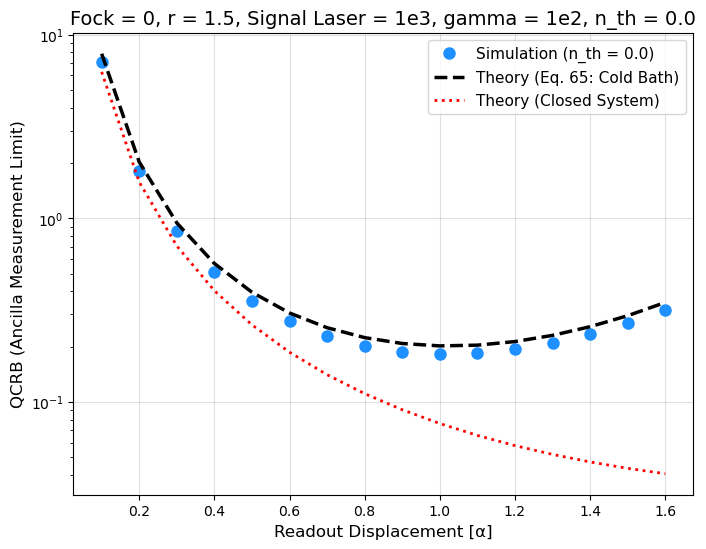

In [12]:
# 1. Get the coordinates for your exact parameters
# (n_fock=0, r_squeeze=0.0, laser_intensity=1e3, gamma=1e-2, n_th=0.0)
x_alpha, y_sim, y_theory_open, y_theory_closed = get_qcrb_coordinates(0, 1.5, 1e3, 1e2, 0.0)

# 2. Create the custom plot
fig = figure(figsize=(8, 6))

# Simulated Data
plot(x_alpha, y_sim, "o", markersize=8, color="dodgerblue", label="Simulation (n_th = 0.0)")

# Open-System Theory (Eq. 65)
plot(x_alpha, y_theory_open, "k--", linewidth=2.5, label="Theory (Eq. 65: Cold Bath)")

# Closed-System Baseline (No Noise)
plot(x_alpha, y_theory_closed, "r:", linewidth=2, label="Theory (Closed System)")

yscale("log")
xlabel("Readout Displacement [α]", fontsize=12)
ylabel("QCRB (Ancilla Measurement Limit)", fontsize=12)
title("Fock = 0, r = 1.5, Signal Laser = 1e3, gamma = 1e2, n_th = 0.0", fontsize=14)
legend(fontsize=11)
grid(alpha=0.4)

display(fig)

 EXACT TIME CALCULATION
 Signal Magnitude (β): 1.0
 Exposure Time (t)   : 2206.67 μs
 Base Gamma Rate     : 100.0
 Thermal Phonons (n) : 0.0

Running master equation for Base β Signal...
Simulating pure continuous Beta displacement with Lindblad noise...

Running master equation for Perturbed β Signal (+ d_beta)...
Simulating pure continuous Beta displacement with Lindblad noise...

Sweeping α readout (generating coordinates)...


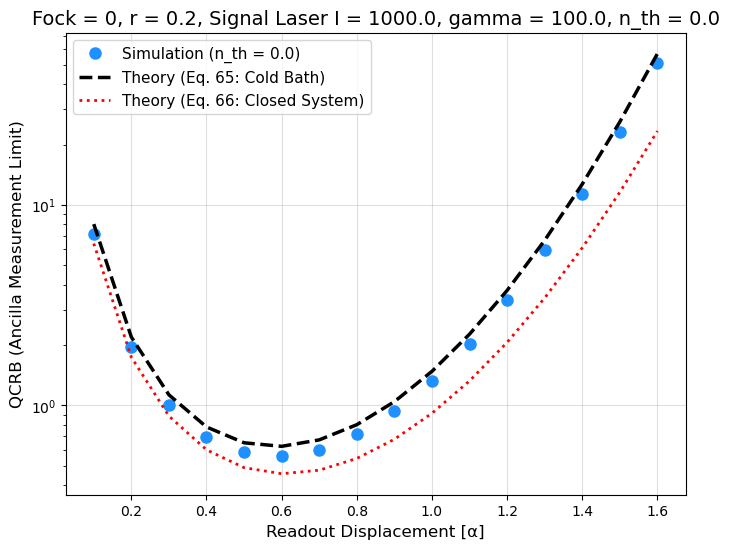

In [18]:
plot_qcrb_results(0, 0.2, 1e3, 1e2, 0.0)

 EXACT TIME CALCULATION
 Signal Magnitude (β): 1.0
 Exposure Time (t)   : 2206.67 μs
 Base Gamma Rate     : 100.0
 Thermal Phonons (n) : 0.0

Running master equation for Base β Signal...
Simulating pure continuous Beta displacement with Lindblad noise...

Running master equation for Perturbed β Signal (+ d_beta)...
Simulating pure continuous Beta displacement with Lindblad noise...

Sweeping α readout (generating coordinates)...


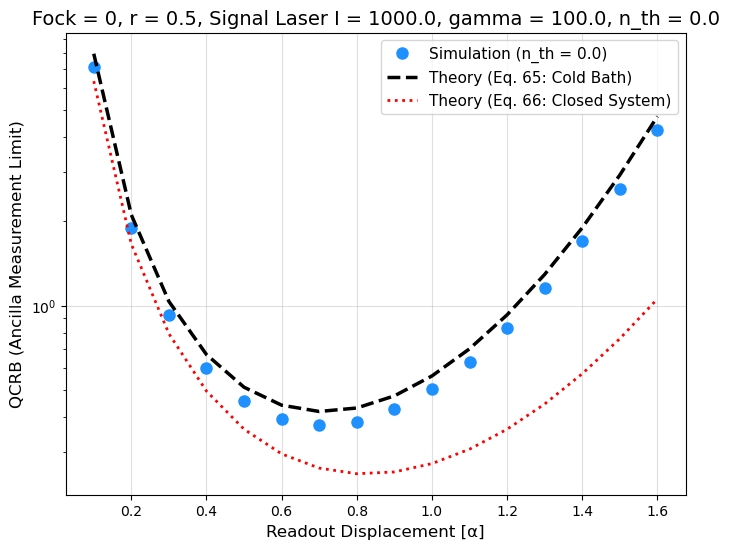

In [19]:
plot_qcrb_results(0, 0.5, 1e3, 1e2, 0.0)

 EXACT TIME CALCULATION
 Signal Magnitude (β): 1.0
 Exposure Time (t)   : 2206.67 μs
 Base Gamma Rate     : 100.0
 Thermal Phonons (n) : 0.0

Running master equation for Base β Signal...
Simulating pure continuous Beta displacement with Lindblad noise...

Running master equation for Perturbed β Signal (+ d_beta)...
Simulating pure continuous Beta displacement with Lindblad noise...

Sweeping α readout (generating coordinates)...


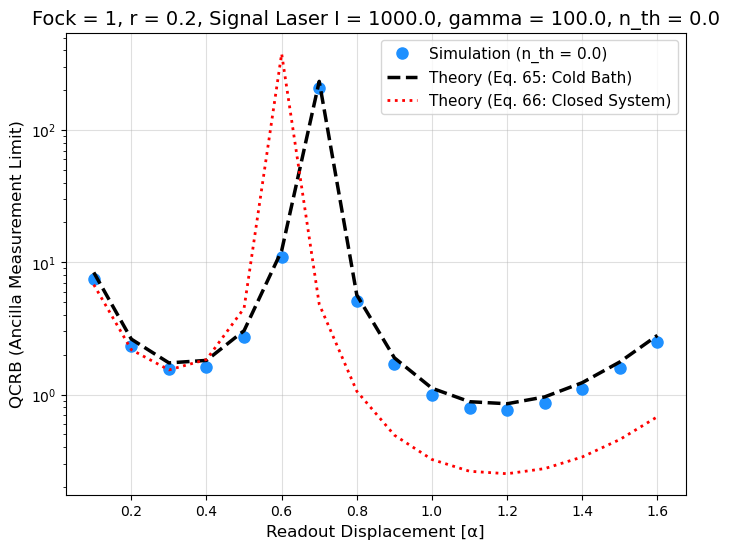

In [20]:
plot_qcrb_results(1, 0.2, 1e3, 1e2, 0.0)

 EXACT TIME CALCULATION
 Signal Magnitude (β): 1.0
 Exposure Time (t)   : 2206.67 μs
 Base Gamma Rate     : 100.0
 Thermal Phonons (n) : 0.0

Running master equation for Base β Signal...
Simulating pure continuous Beta displacement with Lindblad noise...

Running master equation for Perturbed β Signal (+ d_beta)...
Simulating pure continuous Beta displacement with Lindblad noise...

Sweeping α readout (generating coordinates)...


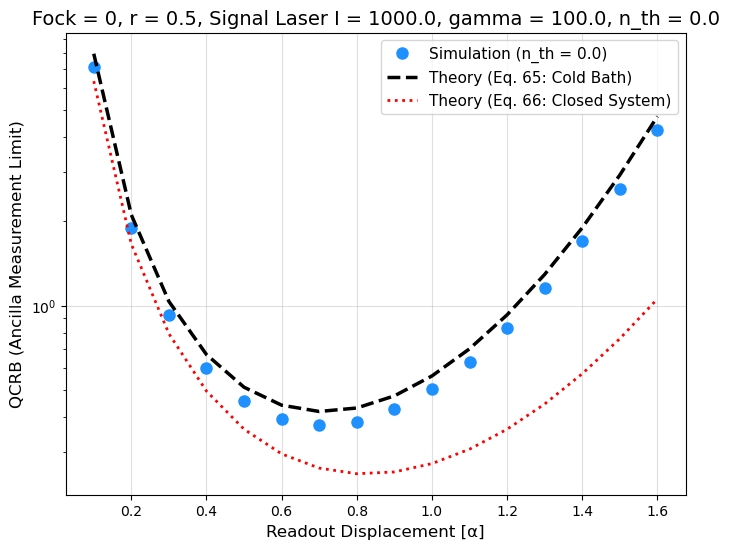

In [21]:
plot_qcrb_results(0, 0.5, 1e3, 1e2, 0.0)

 EXACT TIME CALCULATION
 Signal Magnitude (β): 1.0
 Exposure Time (t)   : 2206.67 μs
 Base Gamma Rate     : 1.0
 Thermal Phonons (n) : 0.0

Running master equation for Base β Signal...
Simulating pure continuous Beta displacement with Lindblad noise...

Running master equation for Perturbed β Signal (+ d_beta)...
Simulating pure continuous Beta displacement with Lindblad noise...

Sweeping α readout (generating coordinates)...


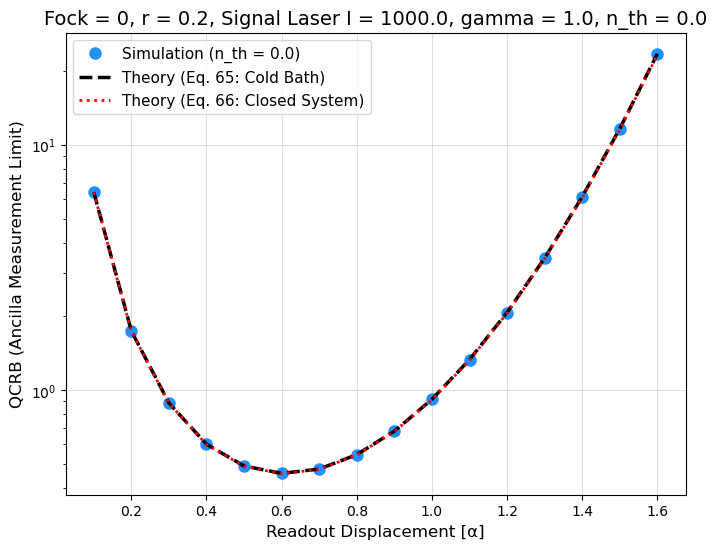

In [23]:
plot_qcrb_results(0, 0.2, 1e3, 1.0, 0.0)

 EXACT TIME CALCULATION
 Signal Magnitude (β): 1.0
 Exposure Time (t)   : 2206.67 μs
 Base Gamma Rate     : 1000.0
 Thermal Phonons (n) : 0.0

Running master equation for Base β Signal...
Simulating pure continuous Beta displacement with Lindblad noise...

Running master equation for Perturbed β Signal (+ d_beta)...
Simulating pure continuous Beta displacement with Lindblad noise...

Sweeping α readout (generating coordinates)...


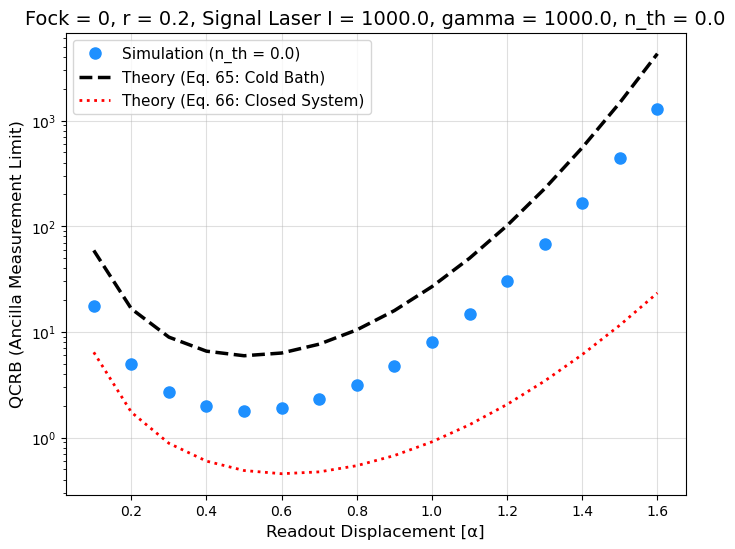

In [24]:
plot_qcrb_results(0, 0.2, 1e3, 1e3, 0.0)

 EXACT TIME CALCULATION
 Signal Magnitude (β): 1.0
 Exposure Time (t)   : 2206.67 μs
 Base Gamma Rate     : 100.0
 Thermal Phonons (n) : 1.0

Running master equation for Base β Signal...
Simulating pure continuous Beta displacement with Lindblad noise...

Running master equation for Perturbed β Signal (+ d_beta)...
Simulating pure continuous Beta displacement with Lindblad noise...

Sweeping α readout (generating coordinates)...


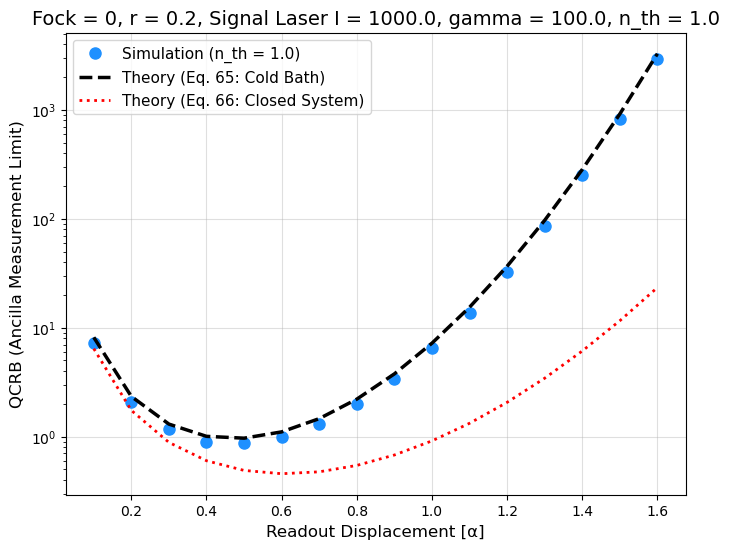

In [25]:
plot_qcrb_results(0, 0.2, 1e3, 1e2, 1.0)

 EXACT TIME CALCULATION
 Signal Magnitude (β): 1.0
 Exposure Time (t)   : 2206.67 μs
 Base Gamma Rate     : 100.0
 Thermal Phonons (n) : 10.0

Running master equation for Base β Signal...
Simulating pure continuous Beta displacement with Lindblad noise...

Running master equation for Perturbed β Signal (+ d_beta)...
Simulating pure continuous Beta displacement with Lindblad noise...

Sweeping α readout (generating coordinates)...


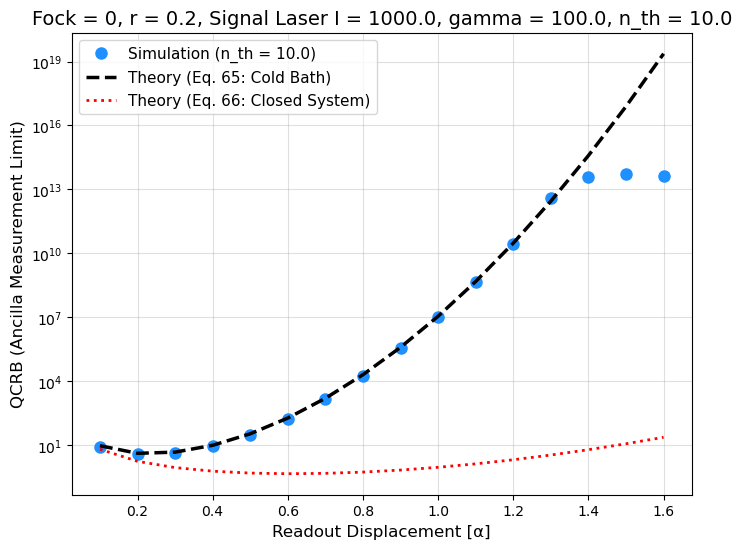

In [26]:
plot_qcrb_results(0, 0.2, 1e3, 1e2, 10.0)

 EXACT TIME CALCULATION
 Signal Magnitude (β): 1.0
 Exposure Time (t)   : 2206.67 μs
 Base Gamma Rate     : 100.0
 Thermal Phonons (n) : 0.0

Running master equation for Base β Signal...
Simulating pure continuous Beta displacement with Lindblad noise...

Running master equation for Perturbed β Signal (+ d_beta)...
Simulating pure continuous Beta displacement with Lindblad noise...

Sweeping α readout (generating coordinates)...


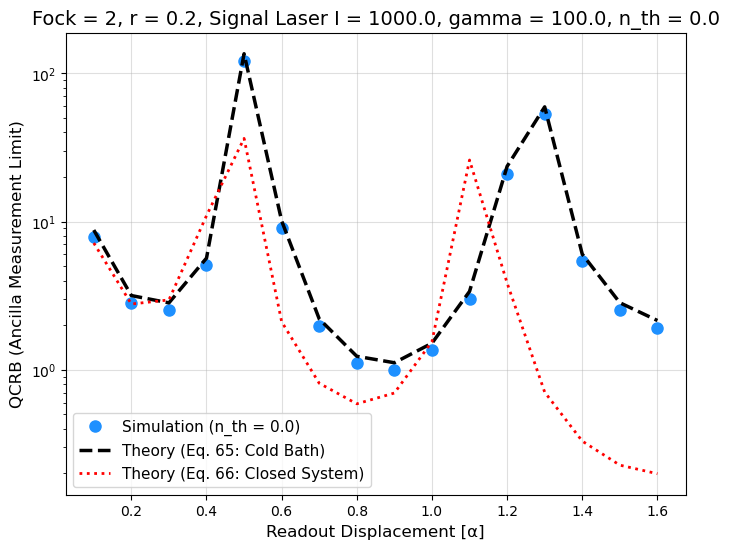

In [27]:
plot_qcrb_results(2, 0.2, 1e3, 1e2, 0.0)

 EXACT TIME CALCULATION
 Signal Magnitude (β): 1.0
 Exposure Time (t)   : 22066.74 μs
 Base Gamma Rate     : 100.0
 Thermal Phonons (n) : 0.0

Running master equation for Base β Signal...
Simulating pure continuous Beta displacement with Lindblad noise...

Running master equation for Perturbed β Signal (+ d_beta)...
Simulating pure continuous Beta displacement with Lindblad noise...

Sweeping α readout (generating coordinates)...


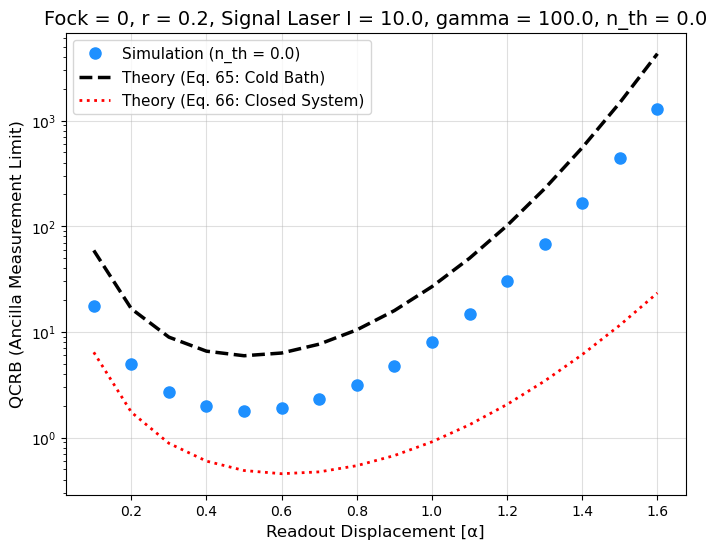

In [29]:
plot_qcrb_results(0, 0.2, 1e1, 1e2, 0.0)

Next potential steps

1. Investigate the analytical function when noise is also injected during alpha separation phase too. 
We have investigated noise after the alpha phase, and here we investigate noise only in signal beta phase. 

We can have most general analytical function of noise in 1. beta, 2. noise in beta + alpha, 3. noise in beta + alpha + rest

we finished 1 only and partially 3 if we find out a way to do 2. 

2. The relation seems to be matching on the high level, but do an actual deviation of how each parameters, n, r, gamma * t  scales the optimal alpha

Since there is three parameters looking at the analytical function, we can have a three dimension plot of each n r gamma*t as its own axis and find the minimum in terms of the analytical function 

3. Our simulation can generalize into heating by setting n_th but then our equation does not support. The equation also do not support dephasing Investigate this and generalize the analytical function into full linbladian (cooling, heating, dephasing)

3. there is a correlation between gamma, t, and the laser intensity for beta stage.
ex. There is a relation between laser and t since we have fixed beta displacement to be 1.0 

Based on the gamma* t value basically determines the Gamma in our equation and that is the noise. Rewrite the equation to also evaluate laser intensity? Or shift beta and see how the optimal changes since noise injection will defer if we fix t or laser intensity instead.


Next steps

Translating the laser intensity into coupling g so that its unit lines up with the gamma noise unit

See the linbladian model behavior with the time with zero laser intensity trap with respect to average n phonon state to see it start at the same but with time progression different decay rate

n state optimal acrb plot

